## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

alcohol_cons_df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
alcohol_cons_df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [3]:
alcohol_cons_updated = alcohol_cons_df.drop("total_litres_of_pure_alcohol", axis=1)
tidy_drink = alcohol_cons_updated.melt(
    id_vars=["country"],
    value_vars=["beer_servings", "spirit_servings", "wine_servings"],
    var_name="drink",
    value_name="servings"
    )
tidy_drink

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217
...,...,...,...
574,Venezuela,wine_servings,3
575,Vietnam,wine_servings,1
576,Yemen,wine_servings,0
577,Zambia,wine_servings,4


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

In [5]:
# Remove "_servings" from the tidy dataframe
tidy_drink["drink"] = tidy_drink["drink"].str.split("_").str[0]
tidy_drink

,country,drink,servings
0,Afghanistan,beer,0
1,Albania,beer,89
2,Algeria,beer,25
3,Andorra,beer,245
4,Angola,beer,217
...,...,...,...
574,Venezuela,wine,3
575,Vietnam,wine,1
576,Yemen,wine,0
577,Zambia,wine,4


Text(0.5, 1.0, 'Top 10 Countries that Drink the Most Beer')

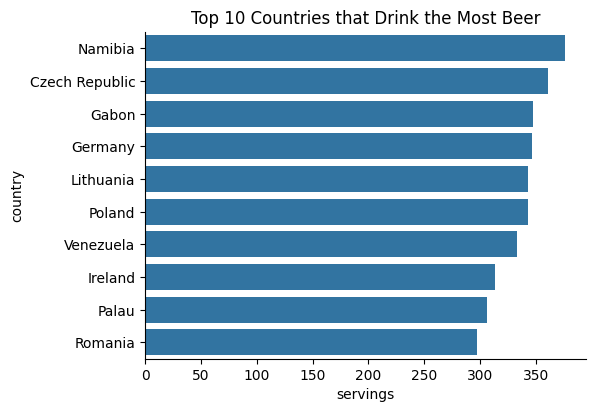

In [19]:
# Top 10 countries that drink the most beer
beer_drinkers = tidy_drink[tidy_drink["drink"] == "beer"]
beer_drinkers_top10 = beer_drinkers.sort_values(by="servings", ascending=False).head(10)

sns.catplot(
    data=beer_drinkers_top10,
    kind="bar",
    x="servings",
    y="country",
    height=4,
    aspect=1.5
)
plt.title("Top 10 Countries that Drink the Most Beer")


Text(0.5, 1.0, 'Top 10 Countries that Drink the Most Spirits')

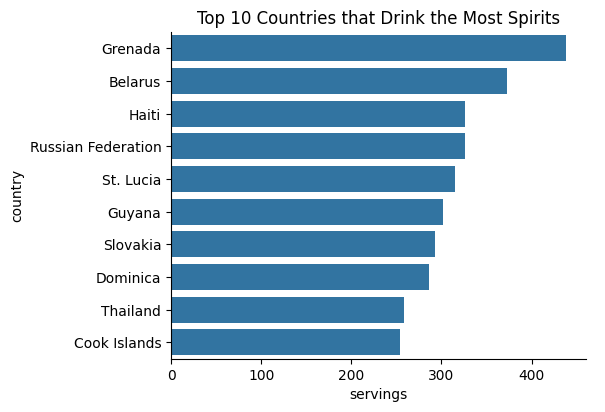

In [21]:
# Top 10 countries that drink the most spirits
spirits_drinkers = tidy_drink[tidy_drink["drink"] == "spirit"]
spirits_drinkers_top10 = spirits_drinkers.sort_values(by="servings", ascending=False).head(10)

sns.catplot(
    data=spirits_drinkers_top10,
    kind="bar",
    x="servings",
    y="country",
    height=4,
    aspect=1.5
)
plt.title("Top 10 Countries that Drink the Most Spirits")

Text(0.5, 1.0, 'Top 10 Countries that Drink the Most Wine')

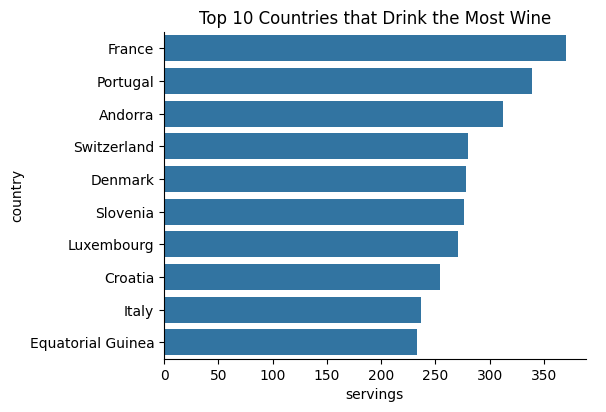

In [22]:
# Top 10 countries that drink the most wine
wine_drinkers = tidy_drink[tidy_drink["drink"] == "wine"]
wine_drinkers_top10 = wine_drinkers.sort_values(by="servings", ascending=False).head(10)

sns.catplot(
    data=wine_drinkers_top10,
    kind="bar",
    x="servings",
    y="country",
    height=4,
    aspect=1.5
)
plt.title("Top 10 Countries that Drink the Most Wine")

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [27]:
pd.pivot_table(
    data=tidy_drink,
    index="country",
    columns="drink",
    values="servings"
)


drink,beer,spirit,wine
country,,,
Afghanistan,0.0,0.0,0.0
Albania,89.0,132.0,54.0
Algeria,25.0,0.0,14.0
Andorra,245.0,138.0,312.0
Angola,217.0,57.0,45.0
...,...,...,...
Venezuela,333.0,100.0,3.0
Vietnam,111.0,2.0,1.0
Yemen,6.0,0.0,0.0
